This full workflow contains from start to finish all the analysis done using the Lidar dataset.

In [1]:
# for dev work

import sys
import importlib
import matplotlib.pyplot as plt
import json
import matplotlib.cm as cm
import matplotlib
import numpy as np
import matplotlib.colors as mcolors

import folium
from folium import plugins
import json

# Add src to path (do this once at the top)
sys.path.insert(0, '../../src')

# Initial import
import park_vga

# After editing:
importlib.reload(park_vga.defining_grids)
importlib.reload(park_vga.lidar)
importlib.reload(park_vga)

<module 'park_vga' from '/Users/maeve/Documents/park-vga/notebooks/modularising_the_approach/../../src/park_vga/__init__.py'>

In [ ]:
boundaries_file = "../../example_datasets/Leeds_pp_or_g_cmb.geojson"
primary_name = "Woodhouse Moor"

buffer_distance = 20 # metres

lidar_dtm = "/Volumes/Extreme SSD/DTM"
lidar_dsm = "/Volumes/Extreme SSD/FZ_DSM"

In [81]:
park_gdf = park_vga.load_data(boundaries_file, primary_name, buffer_distance)

In [82]:
park_files = park_vga.park_geometry_to_file_path(park_gdf, lidar_dtm, lidar_dsm)

In [83]:
if park_files == ([], []):
    print("No files found for park 1")
else:
    print("Files found for park 1")

Files found for park 1


In [84]:
hex_grid = park_vga.create_hexagon_grid(park_gdf, spacing=10, return_mode='both')

Created 2349 pointy-top hexagons (10m vertical spacing)


Above takes 0.1s - very quick

In [85]:
lidar_data = park_vga.load_lidar_rasters_for_park(
    park_gdf, 
    park_files[0],  # dtm_paths
    park_files[1]   # dsm_paths
)

Loading 2 DSM and 2 DTM files
DSM valid pixels: 12500000 of 12500000 (100.0%)
DTM valid pixels: 12500000 of 12500000 (100.0%)
Output shape: (370, 301), Height range: -0.1m to 22.3m


This creates a dictionary with both the DTM and DSM data, takes 0.7 s.

In [86]:
lidar_data.keys()

dict_keys(['dsm', 'dtm', 'height_above_ground', 'dsm_meta', 'dtm_meta', 'transform', 'crs'])

The affine transform lets us convert between pixels to actual geographically meaningful units:

```
(pixel_width, rotation_x, x_origin,
rotation_y, pixel_height,y_origin)
```

- x_origin, y_origin: coordinates of the top-left corner (in whichever CRS is set for the file)
- pixel_width, pixel_height: Size of each pixel in geographic units (usually meters)
- rotation_x, rotation_y: Rotation angles (usually 0 for axis-aligned data)

In [87]:
lidar_data['transform']

Affine(2.0, 0.0, 428674.0,
       0.0, -2.0, 435444.0)

In [88]:
visibility_results_1 = park_vga.calculate_visibility_metrics(
    hex_grid["centroids"], 
    lidar_data['dsm'], 
    lidar_data['dtm'], 
    lidar_data['transform'],
    observer_height=1.0,
    target_height=0,
    max_distance=100
)

Calculating visibility for 2349 points
Processing point 1/2349
Processing point 51/2349
Processing point 101/2349
Processing point 151/2349
Processing point 201/2349
Processing point 251/2349
Processing point 301/2349
Processing point 351/2349
Processing point 401/2349
Processing point 451/2349
Processing point 501/2349
Processing point 551/2349
Processing point 601/2349
Processing point 651/2349
Processing point 701/2349
Processing point 751/2349
Processing point 801/2349
Processing point 851/2349
Processing point 901/2349
Processing point 951/2349
Processing point 1001/2349
Processing point 1051/2349
Processing point 1101/2349
Processing point 1151/2349
Processing point 1201/2349
Processing point 1251/2349
Processing point 1301/2349
Processing point 1351/2349
Processing point 1401/2349
Processing point 1451/2349
Processing point 1501/2349
Processing point 1551/2349
Processing point 1601/2349
Processing point 1651/2349
Processing point 1701/2349
Processing point 1751/2349
Processing p

this took 5m 13.9 s for 2349 tiles

In [ ]:
# Rename current geometry column to 'centroids' and set polygon geometry
visibility_results_1['centroids'] = visibility_results_1.geometry
visibility_results_1 = visibility_results_1.set_geometry(hex_grid["polygons"].geometry)

In [93]:
visibility_results_1.columns

Index(['geometry', 'visible_points', 'total_points', 'visibility_pct',
       'centroids'],
      dtype='str')

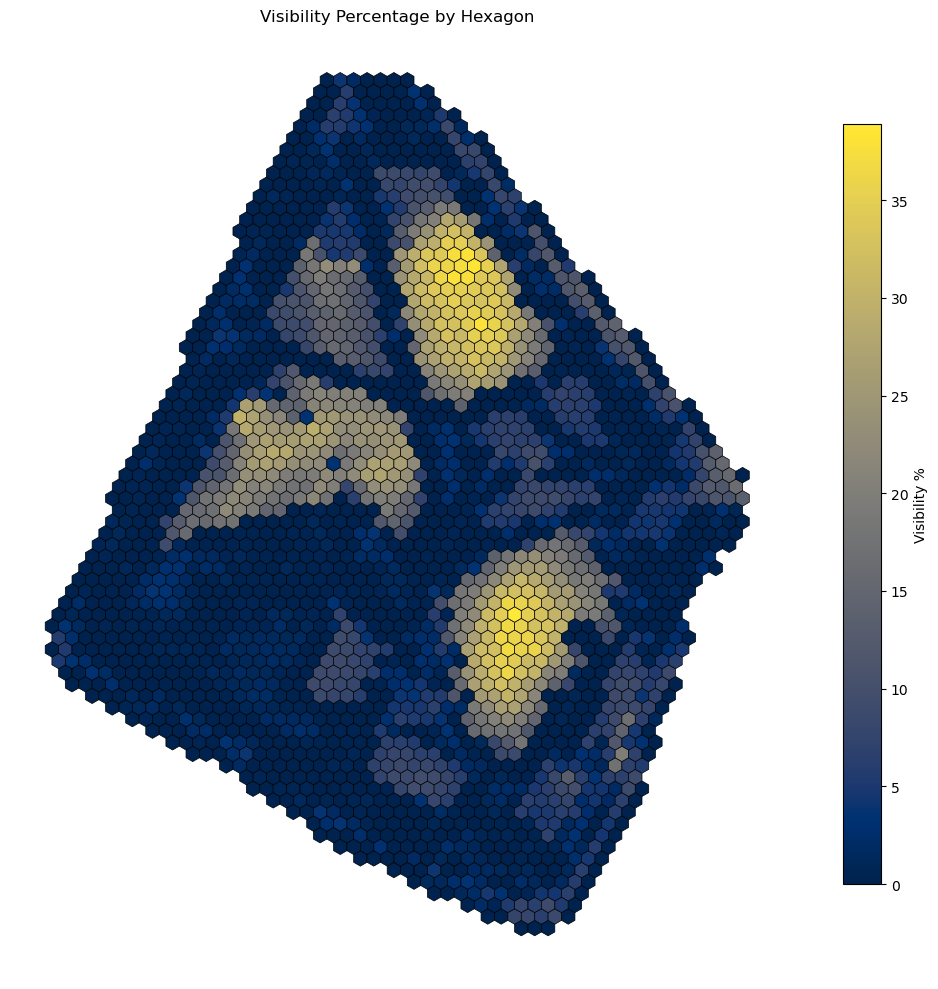

In [94]:
fig, ax = plt.subplots(figsize=(12, 10))
visibility_results_1.plot(column='visibility_pct', 
                          cmap='cividis', 
                          ax=ax,
                          legend=True,
                          edgecolor='k',
                          linewidth=0.5,
                          legend_kwds={'label': 'Visibility %', 'shrink': 0.8})
ax.set_title('Visibility Percentage by Hexagon')
ax.axis('off')
plt.tight_layout()
plt.show()

In [95]:
# Verify geometries are valid
print(visibility_results_1.geometry.is_valid.all())
print(visibility_results_1.crs)

True
EPSG:27700


In [96]:
# Keep hexagons that intersect (touch or overlap) the park boundary
park_original =  park_vga.load_data(boundaries_file, primary_name, 0)
park_boundary = park_original.geometry.iloc[0]

visibility_clipped = visibility_results_1[visibility_results_1.geometry.intersects(park_boundary)]

In [97]:


viz_data = visibility_clipped.drop(columns=['centroids']).to_crs('EPSG:4326')

# Create a center from the reprojected data
center_lat = viz_data.geometry.centroid.y.mean()
center_lon = viz_data.geometry.centroid.x.mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=14,
    tiles='CartoDB positron'
)

# Normalize visibility values to 0-1 for cividis
norm = plt.Normalize(vmin=viz_data['visibility_pct'].min(), vmax=viz_data['visibility_pct'].max())
cmap = cm.get_cmap('cividis')

# Create a color function
def get_color(value):
    return matplotlib.colors.to_hex(cmap(norm(value)))

# Add features with cividis colors
geojson_data = json.loads(viz_data.to_json())

for feature in geojson_data['features']:
    props = feature['properties']
    color = get_color(props['visibility_pct'])
    
    folium.GeoJson(
        data=feature,
        style_function=lambda x, col=color: {
            'fillColor': col,
            'color': 'black',
            'weight': 0.5,
            'fillOpacity': 0.7
        }
    ).add_to(m)

# Add a colorbar
folium.LinearColormap(
    colors=[matplotlib.colors.to_hex(cmap(i/100)) for i in range(101)],
    vmin=viz_data['visibility_pct'].min(),
    vmax=viz_data['visibility_pct'].max(),
    caption='Visibility %'
).add_to(m)

m.show_in_browser()

/var/folders/3s/z86xkbn12m94tfxyzcgrwf080000gn/T/ipykernel_16842/4147294262.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lat = viz_data.geometry.centroid.y.mean()
/var/folders/3s/z86xkbn12m94tfxyzcgrwf080000gn/T/ipykernel_16842/4147294262.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lon = viz_data.geometry.centroid.x.mean()
/var/folders/3s/z86xkbn12m94tfxyzcgrwf080000gn/T/ipykernel_16842/4147294262.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('cividis')
765:773: execution error: S

Your map should have been opened in your browser automatically.
Press ctrl+c to return.


In [ ]:
# # Ensure data is in EPSG:4326 and save
# viz_data = visibility_results_1.drop(columns=['centroids']).to_crs('EPSG:4326')

# # Save to GeoJSON
# output_path = '../../outputs/visibility_results_hexes_clipped.geojson'
# viz_data.to_file(output_path, driver='GeoJSON')

Foliage calculations

In [99]:
hex_polygons = list(zip(
    hex_grid['centroids'].geometry,
    hex_grid['polygons'].geometry
))

In [100]:
foliage_stats = park_vga.extract_foliage_by_hexgrid(
    height_raster=lidar_data['height_above_ground'],
    transform=lidar_data['transform'],
    hex_polygons=hex_polygons,
    min_height=2.0,
    crs='EPSG:27700'
)

Extracting foliage data from 2349 hexagons...
  Processed 234 / 2349 hexagons
  Processed 468 / 2349 hexagons
  Processed 702 / 2349 hexagons
  Processed 936 / 2349 hexagons
  Processed 1170 / 2349 hexagons
  Processed 1404 / 2349 hexagons
  Processed 1638 / 2349 hexagons
  Processed 1872 / 2349 hexagons
  Processed 2106 / 2349 hexagons
  Processed 2340 / 2349 hexagons


In [101]:
foliage_stats = foliage_stats.set_geometry(hex_grid["polygons"].geometry)

<Axes: >

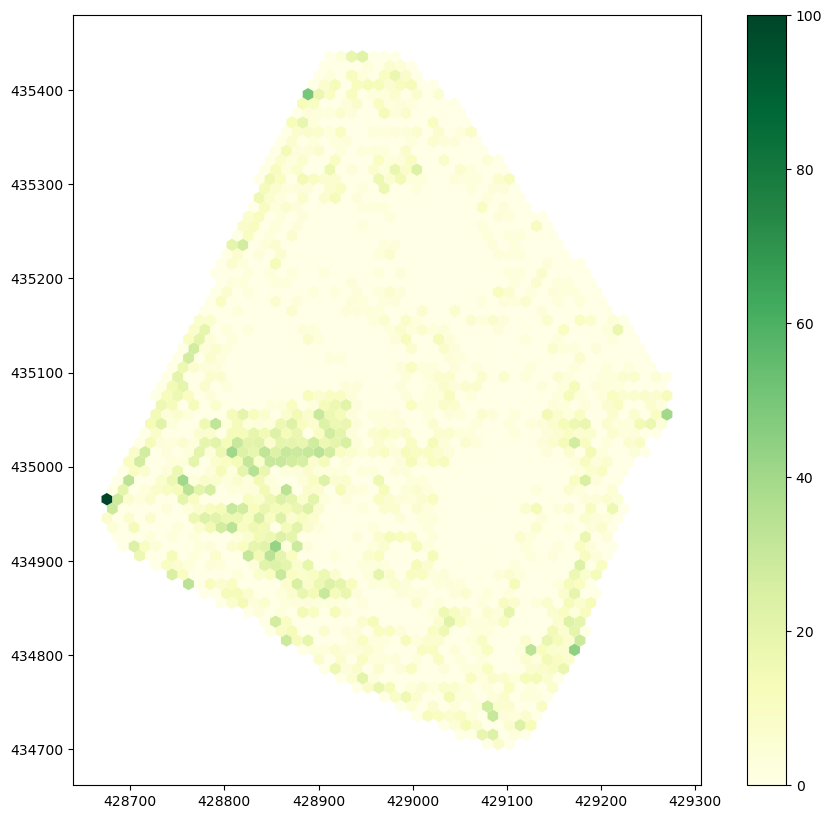

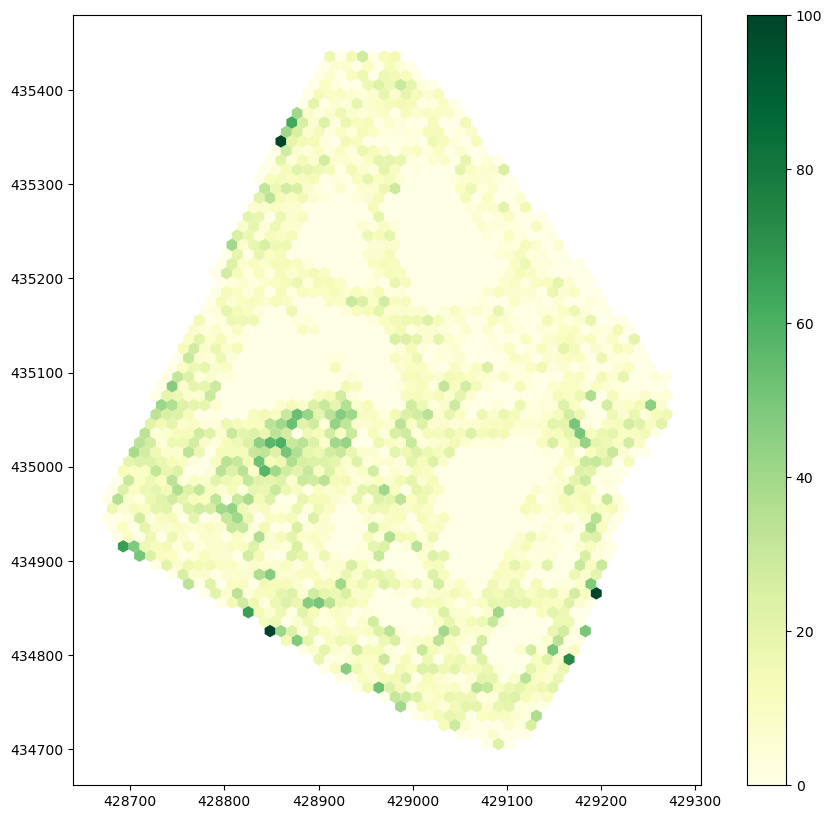

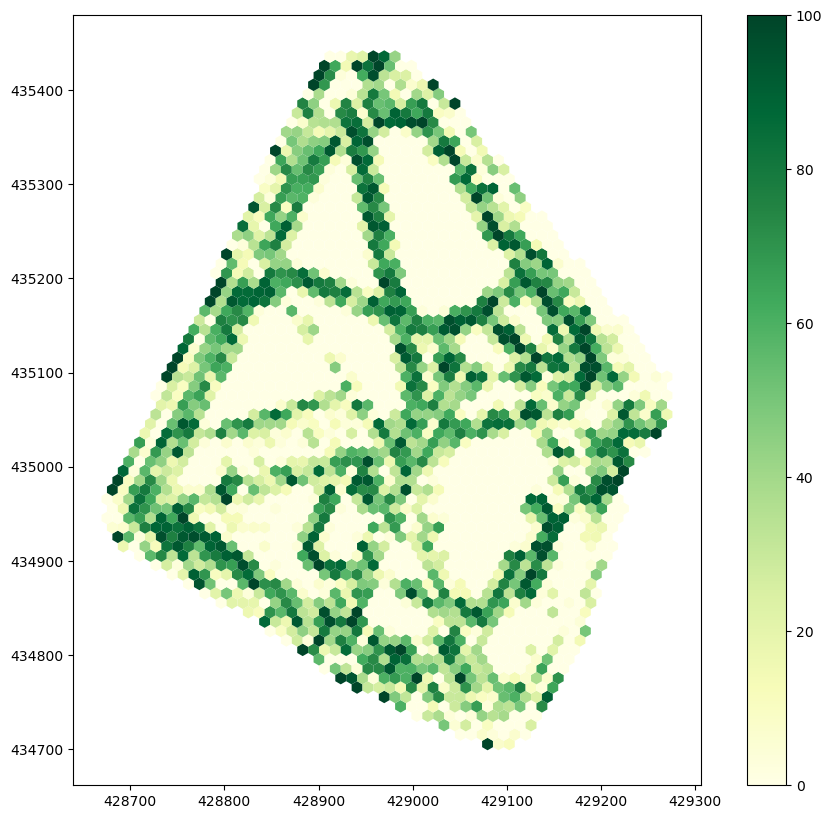

In [102]:
foliage_stats.plot(column='low_level_<0.5', cmap='YlGn', legend=True, figsize=(12, 10))

foliage_stats.plot(column='mid_level_0.5-2', cmap='YlGn', legend=True, figsize=(12, 10))

foliage_stats.plot(column='tall_2+', cmap='YlGn', legend=True, figsize=(12, 10))

In [103]:
# Keep hexagons that intersect (touch or overlap) the park boundary -5 (removing nearby buildings)
park_original =  park_vga.load_data(boundaries_file, primary_name, -5)
park_boundary = park_original.geometry.iloc[0]

foliage_clipped = foliage_stats[foliage_stats.geometry.intersects(park_boundary)]

In [105]:
# Reproject to WGS84
foliage_wgs84 = foliage_clipped.to_crs('EPSG:4326')

# Create map centered on the park
center_lat = foliage_wgs84.geometry.centroid.y.mean()
center_lon = foliage_wgs84.geometry.centroid.x.mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=14,
    tiles='CartoDB positron'
)

# Define the three columns and their properties
layers_config = [
    {'column': 'low_level_<0.5', 'name': 'Low Level (<0.5m)', 'show': True},
    {'column': 'mid_level_0.5-2', 'name': 'Mid Level (0.5-2m)', 'show': True},
    {'column': 'tall_2+', 'name': 'Tall (2m+)', 'show': True},
]

# Create color mapping function with vmin=10
cmap = cm.get_cmap('cividis')

def get_color(value, vmin=10, vmax=100):
    if value < vmin:
        return None  # No color for values below vmin
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    return mcolors.to_hex(cmap(norm(value)))

# Create a layer for each column
for layer_config in layers_config:
    column = layer_config['column']
    layer_name = layer_config['name']
    
    # Convert to GeoJSON
    geojson_data = json.loads(foliage_wgs84.to_json())
    
    # Create a FeatureGroup for this layer
    fg = folium.FeatureGroup(name=layer_name, show=layer_config['show'])
    
    # Add each feature with appropriate styling
    for feature in geojson_data['features']:
        props = feature['properties']
        value = props.get(column)
        
        if value is not None and value >= 10:
            color = get_color(value)
            folium.GeoJson(
                data=feature,
                style_function=lambda x, col=color: {
                    'fillColor': col,
                    'color': 'black',
                    'weight': 0.5,
                    'fillOpacity': 0.7
                }
            ).add_to(fg)
    
    fg.add_to(m)

# Add layer control to toggle layers on/off
folium.LayerControl().add_to(m)

m.show_in_browser()

/var/folders/3s/z86xkbn12m94tfxyzcgrwf080000gn/T/ipykernel_16842/3298525412.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lat = foliage_wgs84.geometry.centroid.y.mean()
/var/folders/3s/z86xkbn12m94tfxyzcgrwf080000gn/T/ipykernel_16842/3298525412.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lon = foliage_wgs84.geometry.centroid.x.mean()
/var/folders/3s/z86xkbn12m94tfxyzcgrwf080000gn/T/ipykernel_16842/3298525412.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('cividis')
765:773: executio

Your map should have been opened in your browser automatically.
Press ctrl+c to return.


In [ ]:
# Ensure data is in EPSG:4326 and save
# foliage_wgs84 = foliage_clipped.to_crs('EPSG:4326')

# # Save to GeoJSON
# output_path = '../../outputs/foliage_results_hexes_clipped.geojson'
# foliage_wgs84.to_file(output_path, driver='GeoJSON')

In [108]:
# Reproject to WGS84
viz_data = visibility_clipped.drop(columns=['centroids']).to_crs('EPSG:4326')
foliage_wgs84 = foliage_clipped.to_crs('EPSG:4326')
park_boundary_wgs84 = park_original.to_crs('EPSG:4326')

# Create map
center_lat = foliage_wgs84.geometry.centroid.y.mean()
center_lon = foliage_wgs84.geometry.centroid.x.mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=14,
    tiles='CartoDB positron'
)

# ===== PARK BOUNDARY LINE =====
park_geojson = json.loads(park_boundary_wgs84.to_json())
folium.GeoJson(
    park_geojson,
    style_function=lambda x: {
        'color': 'red',
        'weight': 3,
        'opacity': 0.8,
        'fill': False
    },
    name='Park Boundary'
).add_to(m)

# ===== VISIBILITY LAYER =====
viz_cmap = cm.get_cmap('cividis')
viz_min = viz_data['visibility_pct'].min()
viz_max = viz_data['visibility_pct'].max()
viz_norm = mcolors.Normalize(vmin=viz_min, vmax=viz_max)

def get_viz_color(value):
    return mcolors.to_hex(viz_cmap(viz_norm(value)))

viz_fg = folium.FeatureGroup(name='Visibility %', show=True)
viz_geojson = json.loads(viz_data.to_json())

for feature in viz_geojson['features']:
    props = feature['properties']
    value = props.get('visibility_pct')
    color = get_viz_color(value)
    
    folium.GeoJson(
        data=feature,
        style_function=lambda x, col=color: {
            'fillColor': col,
            'color': 'black',
            'weight': 0.3,
            'fillOpacity': 0.7
        }
    ).add_to(viz_fg)

viz_fg.add_to(m)

# Visibility colorbar
folium.LinearColormap(
    colors=[mcolors.to_hex(viz_cmap(i/100)) for i in range(101)],
    vmin=viz_min,
    vmax=viz_max,
    caption='Visibility %'
).add_to(m)

# ===== FOLIAGE LAYERS =====
foliage_layers = [
    {'column': 'low_level_<0.5', 'name': 'Low Level (<0.5m)', 'colormap': 'Greens'},
    {'column': 'mid_level_0.5-2', 'name': 'Mid Level (0.5-2m)', 'colormap': 'Blues'},
    {'column': 'tall_2+', 'name': 'Tall (2m+)', 'colormap': 'Oranges'},
]

foliage_geojson = json.loads(foliage_wgs84.to_json())

for layer_config in foliage_layers:
    column = layer_config['column']
    layer_name = layer_config['name']
    colormap_name = layer_config['colormap']
    
    cmap = cm.get_cmap(colormap_name)
    norm = mcolors.Normalize(vmin=10, vmax=100)
    
    fg = folium.FeatureGroup(name=layer_name, show=False)
    
    for feature in foliage_geojson['features']:
        props = feature['properties']
        value = props.get(column)
        
        if value is not None and value >= 10:
            color = mcolors.to_hex(cmap(norm(value)))
            folium.GeoJson(
                data=feature,
                style_function=lambda x, col=color: {
                    'fillColor': col,
                    'color': 'black',
                    'weight': 0.3,
                    'fillOpacity': 0.7
                }
            ).add_to(fg)
    
    fg.add_to(m)
    
    # Add colorbar for each foliage layer
    folium.LinearColormap(
        colors=[mcolors.to_hex(cmap(i/100)) for i in range(10, 101)],
        vmin=10,
        vmax=100,
        caption=layer_name
    ).add_to(m)

# Layer control
folium.LayerControl().add_to(m)

m.show_in_browser()

/var/folders/3s/z86xkbn12m94tfxyzcgrwf080000gn/T/ipykernel_16842/3927975283.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lat = foliage_wgs84.geometry.centroid.y.mean()
/var/folders/3s/z86xkbn12m94tfxyzcgrwf080000gn/T/ipykernel_16842/3927975283.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lon = foliage_wgs84.geometry.centroid.x.mean()
/var/folders/3s/z86xkbn12m94tfxyzcgrwf080000gn/T/ipykernel_16842/3927975283.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viz_cmap = cm.get_cmap('cividis')
/var/folders/

Your map should have been opened in your browser automatically.
Press ctrl+c to return.
